<a href="https://colab.research.google.com/github/jaykkim1/KNOC_KPA_2026/blob/main/gradio_%EC%8B%A4%EC%8B%9C%EA%B0%84_%EB%82%A0%EC%94%A8%ED%99%95%EC%9D%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

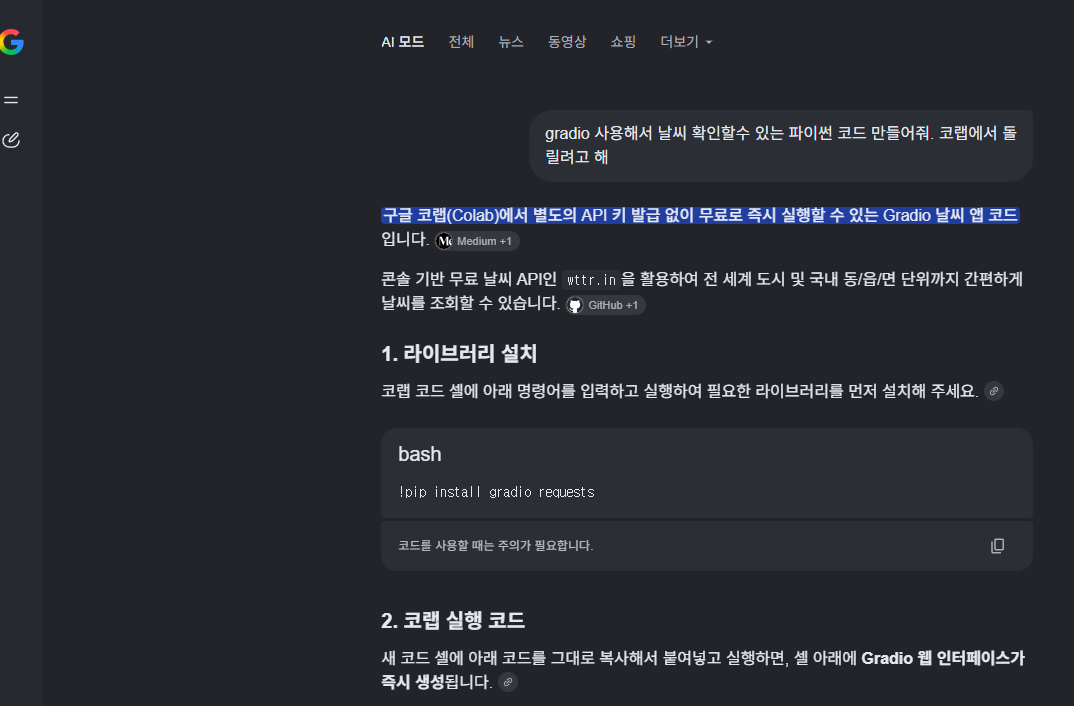

In [ ]:
!pip install gradio requests


In [ ]:
import gradio as gr
import requests

def get_weather(location):
    # 빈 입력값 처리
    if not location.strip():
        return "도시 또는 지역 이름을 입력해주세요."

    # wttr.in API를 사용하여 JSON 형식으로 날씨 정보 가져오기 (언어는 한국어)
    url = f"https://wttr.in/{location}?format=j1&lang=ko"

    try:
        response = requests.get(url)
        # 지역을 찾지 못한 경우 오류 처리
        if response.status_code != 200:
            return f"'{location}' 지역을 찾을 수 없거나 API 오류가 발생했습니다."

        data = response.json()

        # 현재 날씨 데이터 추출
        current = data['current_condition'][0]
        temp_c = current['temp_C']  # 현재 온도
        feels_like = current['FeelsLikeC']  # 체감 온도
        weather_desc = current['lang_ko'][0]['value']  # 날씨 상태 설명 (한국어)
        humidity = current['humidity']  # 습도
        wind_speed = current['windspeedKmph']  # 풍속

        # 출력할 텍스트 포맷팅
        result = (
            f"📍 **조회 지역:** {location}\n"
            f"🌤️ **날씨 상태:** {weather_desc}\n"
            f"🌡️ **현재 온도:** {temp_c}°C (체감 {feels_like}°C)\n"
            f"💧 **습도:** {humidity}%\n"
            f"💨 **풍속:** {wind_speed} km/h"
        )
        return result

    except Exception as e:
        return f"날씨 정보를 가져오는 중 오류가 발생했습니다: {str(e)}"

# Gradio 인터페이스 구성
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🌦️ 실시간 날씨 확인 앱")
    gr.Markdown("원하는 도시나 지역 명을 입력하고 검색해보세요. (예: 서울, 부산, New York, 강남구)")

    with gr.Row():
        input_text = gr.Textbox(label="지역 입력", placeholder="지역 이름을 입력하세요 (예: 서울)")
        submit_btn = gr.Button("날씨 조회", variant="primary")

    output_text = gr.Markdown(label="날씨 결과")

    # 엔터키를 누르거나 버튼을 클릭했을 때 작동
    input_text.submit(get_weather, inputs=input_text, outputs=output_text)
    submit_btn.click(get_weather, inputs=input_text, outputs=output_text)

# 코랩 환경에서 실행 (inline으로 출력됨)
demo.launch(debug=True)


/tmp/ipykernel_588/29732146.py:42: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://3cb7ce25bb446f26d2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7861 <> https://3cb7ce25bb446f26d2.gradio.live
